# Lattice-encrypted OFDM Simulation using Modular Library
This notebook imports the modular functions from `simulation_library` and executes the full simulation pipeline in a single cell, outputting all requested visualizations and metrics.

In [7]:
# 1. Import libraries
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
import sionna
import sionna.phy

# IPython magic function for inline plots
%matplotlib inline

# Import from our modular library
from lattice import LatticeBasedEncryptor, qam16_lattice_to_normalized, qam16_slicer_lattice
from metrics import hadamard_ratio, hadamard_quality, matrix_condition_number, random_unimodular_matrix, generate_lattice_bases
from ber import bit_error_rate, llr_to_bits, nearest_neighbor_qam_demapper, db_to_linear_amplitude, receiver_amplifier
from plots import plot_constellation, plot_rx_only, plot_signal_snapshot, plot_zoomed_signal, plot_noisy_time_domain

## End-to-End Simulation & Visualizations
Run the cell below to execute the full chain (Data generation -> Mapping -> Encryption -> OFDM modulation -> Attenuating AWGN Channel -> Receiver Amplifier -> Equalized Demodulation -> Linear/Babai decryption -> Hard Demapping) and plot the results.

R quality: good
Hadamard ratio R: 1.000000e+00
B quality: good
Hadamard ratio B: 8.808443e-01
Condition number B: 3.386293e+01
Note: B is not below badTh=0.01. That is acceptable for this OFDM mini-simulation because numerical stability matters.
Private basis R shape: torch.Size([256, 256])
Public basis B shape: torch.Size([256, 256])
Hadamard ratio R: 1.0
Hadamard ratio B: 0.8808443222596086
Condition number B: 33.86293042924635

--- TRANSMITTED SIGNAL SNAPSHOT AND ZOOM ---


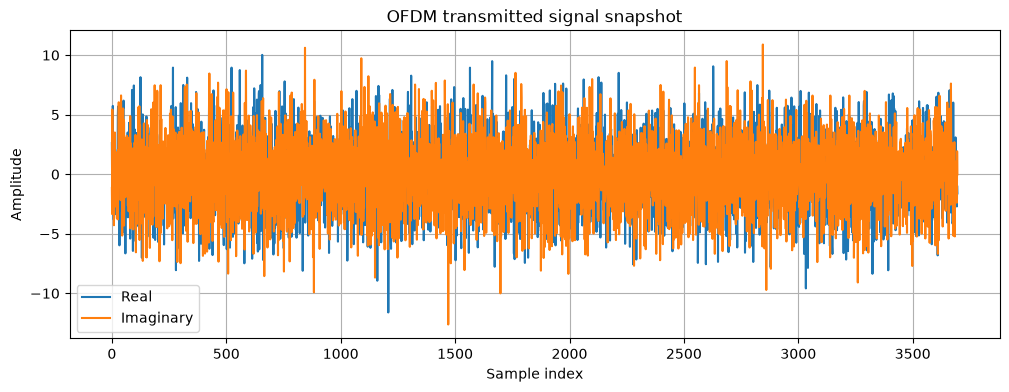

t0: symbol = 2.6171-1.1613j, I = 2.6171, Q = -1.1613
t1: symbol = -0.5414-3.3460j, I = -0.5414, Q = -3.3460
t2: symbol = -0.3387+5.4255j, I = -0.3387, Q = 5.4255
t3: symbol = -1.3746+1.8395j, I = -1.3746, Q = 1.8395


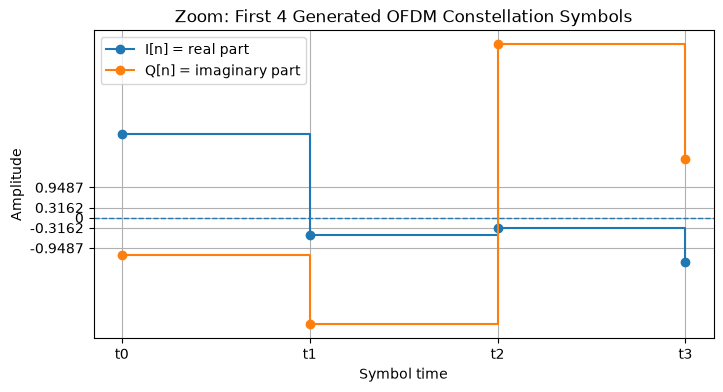

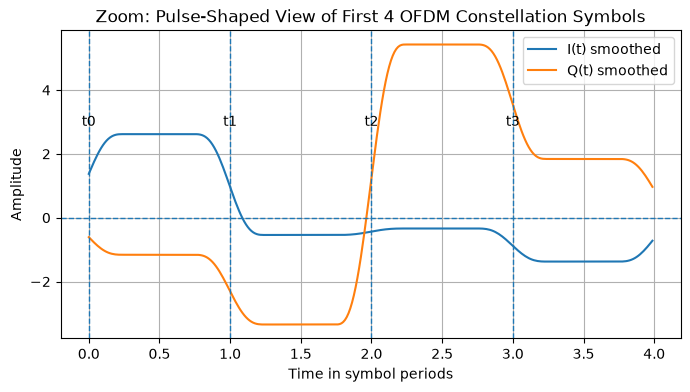


--- NOISY TIME DOMAIN OF OFDM SAMPLES ---


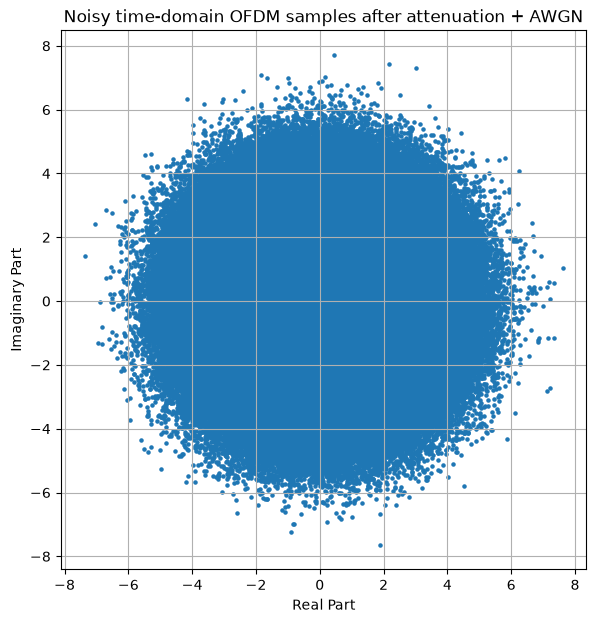


--- ENCRYPTED RECEIVED CONSTELLATION ---


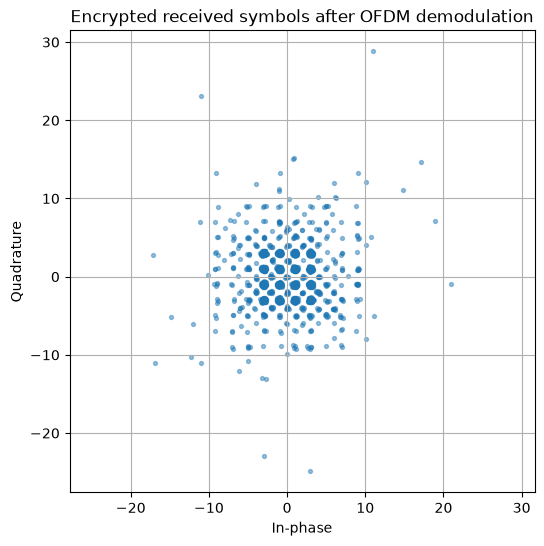

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.



--- DECRYPTED RECEIVED CONSTELLATION PLOTS ---


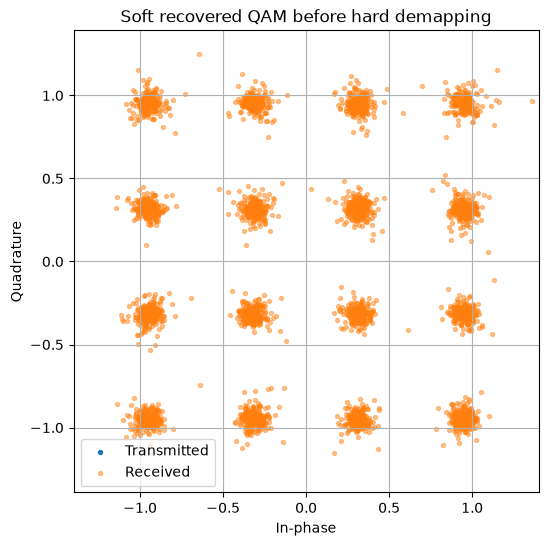

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


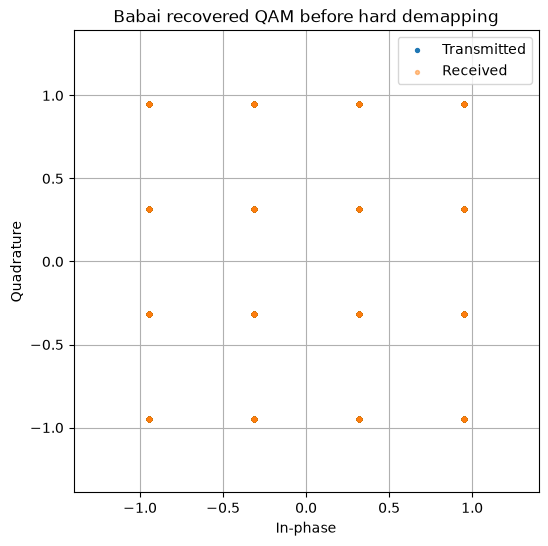


--- COMPUTATIONS AND RESULTS ---
Soft recovery symbol error: 5.870625e-02
Babai recovery symbol error: 1.723372e-04
Soft Sionna-demapped BER: 1.899414e-04
Babai + QAM Sliced BER: 1.590402e-05


In [8]:
# --- PARAMETERS ---
batch_size = 1000
num_bits_per_symbol = 4
fft_size = 256
num_ofdm_symbols = 14
cyclic_prefix_length = 8
ebno_db = 15  # Eb/N0 dB setting
channel_attenuation = 0.5
receiver_gain_db = 7.0  # Receiver gain in dB

# 1. Generate bits
binary_source = sionna.phy.mapping.BinarySource()
bits = binary_source([batch_size, num_ofdm_symbols, fft_size, num_bits_per_symbol])

# 2. Map bits to QAM symbols
constellation = sionna.phy.mapping.Constellation("qam", num_bits_per_symbol)
mapper = sionna.phy.mapping.Mapper(constellation=constellation)
demapper = sionna.phy.mapping.Demapper("app", constellation=constellation)
symbols = mapper(bits)

# 3. Lattice Based Encryption Setup
qam_lattice_scale = torch.sqrt(torch.tensor(10.0, dtype=torch.float32))
encryptor = LatticeBasedEncryptor(
    n=fft_size,
    sigma=0.001,
    num_ops=47,
    max_coeff=2,
    badTh=0.01,
    max_cond=1e5
)

symbols_lattice = symbols.squeeze(-1) * qam_lattice_scale.to(symbols.device)
encrypted_symbols = encryptor.encrypt(symbols_lattice)

# 4. OFDM Modulation
ofdm_modulator = sionna.phy.ofdm.OFDMModulator(cyclic_prefix_length=cyclic_prefix_length)
tx_signal = ofdm_modulator(encrypted_symbols)

# --- VISUALIZATION OF TRANSMITTED SIGNAL ---
print("\n--- TRANSMITTED SIGNAL SNAPSHOT AND ZOOM ---")
plot_signal_snapshot(tx_signal)
plot_zoomed_signal(tx_signal, n_symbols=4, samples_per_symbol=80)

# 5. Attenuate and add AWGN channel
tx_signal_attenuated = channel_attenuation * tx_signal
awgn = sionna.phy.channel.AWGN()
noise = sionna.phy.utils.ebnodb2no(ebno_db, num_bits_per_symbol, coderate=1)
rx_signal = awgn(tx_signal_attenuated, noise)

# --- VISUALIZATION OF NOISY TIME DOMAIN ---
print("\n--- NOISY TIME DOMAIN OF OFDM SAMPLES ---")
plot_noisy_time_domain(rx_signal)

# 6. Receiver Amplifier, OFDM Demodulation & Equalization
rx_signal_amp = receiver_amplifier(rx_signal, gain_db=receiver_gain_db)

ofdm_demodulator = sionna.phy.ofdm.OFDMDemodulator(
    fft_size=fft_size,
    cyclic_prefix_length=cyclic_prefix_length,
    l_min=0
)
rx_symbols = ofdm_demodulator(rx_signal_amp)
effective_gain = channel_attenuation * db_to_linear_amplitude(receiver_gain_db)
rx_symbols_equalized = rx_symbols / effective_gain

# --- VISUALIZATION OF ENCRYPTED CONSTELLATION ---
print("\n--- ENCRYPTED RECEIVED CONSTELLATION ---")
plot_rx_only(rx_symbols_equalized[0], "Encrypted received symbols after OFDM demodulation")

# 7. Soft Decryption & LLR recovery
decrypted_lattice_soft = encryptor.decrypt_linear(rx_symbols_equalized)
decrypted_symbols_soft = qam16_lattice_to_normalized(decrypted_lattice_soft)
llr_soft = demapper(decrypted_symbols_soft, noise)
recovered_bits_soft = llr_to_bits(llr_soft, reference_bits=bits)
ber_soft = bit_error_rate(bits, recovered_bits_soft)

# 8. Babai Decryption & Slicing
decrypted_lattice_babai = encryptor.decrypt_w_babai(rx_symbols_equalized, use_round=True)
decrypted_lattice_babai_sliced = qam16_slicer_lattice(decrypted_lattice_babai)
decrypted_symbols_babai = qam16_lattice_to_normalized(decrypted_lattice_babai_sliced)
recovered_bits_babai = nearest_neighbor_qam_demapper(decrypted_symbols_babai, mapper, num_bits_per_symbol)
ber_babai = bit_error_rate(bits, recovered_bits_babai)

# --- VISUALIZATION OF DECRYPTED CONSTELLATIONS ---
print("\n--- DECRYPTED RECEIVED CONSTELLATION PLOTS ---")
plot_constellation(
    symbols.squeeze(-1)[0],
    decrypted_symbols_soft[0],
    "Soft recovered QAM before hard demapping",
    limit=1.4
)
plot_constellation(
    symbols.squeeze(-1)[0],
    decrypted_symbols_babai[0],
    "Babai recovered QAM before hard demapping",
    limit=1.4
)

# --- METRIC COMPUTATIONS ---
print("\n--- COMPUTATIONS AND RESULTS ---")
print(f"Soft recovery symbol error: {torch.mean(torch.abs(symbols.squeeze(-1) - decrypted_symbols_soft)).item():.6e}")
print(f"Babai recovery symbol error: {torch.mean(torch.abs(symbols_lattice - decrypted_lattice_babai)).item():.6e}")
print(f"Soft Sionna-demapped BER: {ber_soft:.6e}")
print(f"Babai + QAM Sliced BER: {ber_babai:.6e}")